# Практическая работа 2 Обучение с учителем

## Часть 1 Подготовка датасета

### Подключение библиотек

In [32]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn import metrics
from sklearn.metrics import confusion_matrix, f1_score, classification_report
import seaborn as sns
%matplotlib inline



# ЯЧЕЙКА С ОБЪЯСНЕНИЕМ НОВЫХ БИБЛИОТЕК
print("=" * 70)
print("ОБЪЯСНЕНИЕ НОВЫХ БИБЛИОТЕК")
print("=" * 70)

print("""
1. sklearn.linear_model.Lasso
   - L1-регуляризованная линейная регрессия
   - Добавляет штраф, пропорциональный абсолютному значению коэффициентов
   - Может обнулять неважные признаки (автоматический отбор признаков)
   - Полезен при большом количестве потенциально неинформативных признаков

2. sklearn.linear_model.Ridge
   - L2-регуляризованная линейная регрессия
   - Добавляет штраф, пропорциональный квадрату коэффициентов
   - Уменьшает все коэффициенты, но не обнуляет их
   - Хорошо работает при мультиколлинеарности признаков

3. sklearn.linear_model.ElasticNet
   - Комбинация L1 и L2 регуляризации (Lasso + Ridge)
   - Параметр l1_ratio контролирует соотношение между ними
   - Сочетает отбор признаков (как Lasso) и устойчивость (как Ridge)

4. sklearn.svm.SVC
   - Метод опорных векторов (Support Vector Classifier)
   - Ищет оптимальную разделяющую гиперплоскость между классами
   - Может использовать разные ядра (linear, poly, rbf, sigmoid)
   - Эффективен при большом числе признаков

5. sklearn.pipeline.Pipeline
   - Инструмент для последовательного применения преобразований
   - Объединяет масштабирование и обучение модели в один объект
   - Упрощает код и предотвращает утечку данных при кросс-валидации

6. sklearn.preprocessing.StandardScaler
   - Стандартизация признаков (z-score нормализация)
   - Приводит каждый признак к среднему 0 и стандартному отклонению 1
   - Необходим для методов, чувствительных к масштабу (SVM, PCA, градиентный спуск)

7. sklearn.ensemble.RandomForestClassifier
   - Ансамблевый метод на основе деревьев решений
   - Обучает множество деревьев на разных подвыборках данных
   - Итоговое предсказание — голосование деревьев
   - Устойчив к переобучению и выбросам

8. sklearn.model_selection.cross_val_score
   - Выполняет кросс-валидацию и возвращает оценки качества
   - Позволяет оценить стабильность модели на разных данных
   - K-Fold разбиение: данные делятся на K частей, модель обучается K раз

9. sklearn.model_selection.cross_validate
   - Расширенная версия cross_val_score
   - Возвращает время обучения и предсказания, а также метрики
   - Позволяет оценить производительность модели

10. seaborn (sns)
    - Библиотека для статистической визуализации данных
    - Построена поверх matplotlib, но имеет более высокоуровневый API
    - Умеет автоматически строить легенды, палитры, доверительные интервалы
    - Особенно хороша для тепловых карт (heatmap), pairplot, boxplot

11. warnings
    - Модуль для управления предупреждениями Python
    - warnings.filterwarnings('ignore') — подавляет вывод предупреждений
    - Используется, когда предупреждения отвлекают или неинформативны
    - После подавления нужно вернуть warnings.filterwarnings('default')
""")

print("=" * 70)

ОБЪЯСНЕНИЕ НОВЫХ БИБЛИОТЕК

1. sklearn.linear_model.Lasso
   - L1-регуляризованная линейная регрессия
   - Добавляет штраф, пропорциональный абсолютному значению коэффициентов
   - Может обнулять неважные признаки (автоматический отбор признаков)
   - Полезен при большом количестве потенциально неинформативных признаков

2. sklearn.linear_model.Ridge
   - L2-регуляризованная линейная регрессия
   - Добавляет штраф, пропорциональный квадрату коэффициентов
   - Уменьшает все коэффициенты, но не обнуляет их
   - Хорошо работает при мультиколлинеарности признаков

3. sklearn.linear_model.ElasticNet
   - Комбинация L1 и L2 регуляризации (Lasso + Ridge)
   - Параметр l1_ratio контролирует соотношение между ними
   - Сочетает отбор признаков (как Lasso) и устойчивость (как Ridge)

4. sklearn.svm.SVC
   - Метод опорных векторов (Support Vector Classifier)
   - Ищет оптимальную разделяющую гиперплоскость между классами
   - Может использовать разные ядра (linear, poly, rbf, sigmoid)
   - Эффект

### Загрузка датасета

In [33]:
df = pd.read_csv('21 fridges.csv')
print('Dataset shape:', df.shape)
print(df.head(3))
# Датасет содержит 20000 строк и 14 столбцов (7 осмысленных + 7 шумовых)
# Выводим размер и первые 3 строки для ознакомления

Dataset shape: (20000, 14)
       Brand   Model  Capacity Energy Rating          Type  \
0  Panasonic  Model0     369.0           A++           NaN   
1         GE  Model1     619.0             A  Side-by-Side   
2         GE  Model2     309.0             A   Single Door   

             Features  Color         Material  Warranty Period  \
0                 NaN    NaN  Stainless Steel              5.0   
1  Smart Connectivity  White            Glass              8.0   
2       Ice Dispenser  Black  Stainless Steel              7.0   

  Country of Manufacture   Price  Random Numeric Feature 1  \
0                Germany  1231.0                    3984.0   
1                Germany   267.0                    3155.0   
2                  India   477.0                    2218.0   

  Random Text Feature 2 Irrelevant Category Feature 3  
0                 Text0                     Category3  
1                 Text1                     Category3  
2                 Text2                   

### Обработка датасета

In [34]:
# УДАЛЯЕМ указанные поля: Model, Random Numeric Feature 1, Random Text Feature 2, Irrelevant Category Feature 3
df = df.drop(['Model', 'Random Numeric Feature 1', 'Random Text Feature 2', 'Irrelevant Category Feature 3'], axis=1)

# ВАЖНО: заполняем пропуски в Features ДО dropna
df['Features'] = df['Features'].fillna('None')

# Удаление пустых строк (теперь удалится намного меньше)
df = df.dropna()
print(f'Размер датасета после очистки: {df.shape[0]} строк')

# ========== ОБРАБОТКА ПРИЗНАКОВ ==========

# 1. Energy Rating (A++ > A+ > A > B)
energy_map = {'A++': 4, 'A+': 3, 'A': 2, 'B': 1}
df['Energy Rating'] = df['Energy Rating'].map(energy_map).fillna(0).astype(int)

# 2. Type
type_map = {'Side-by-Side': 3, 'Double Door': 2, 'Single Door': 1, 'None': 0}
df['Type'] = df['Type'].map(type_map).fillna(0).astype(int)

# 3. Brand — текст в числа
df['Brand'] = df['Brand'].str.strip()
brands = {
    'Panasonic': 0, 'GE': 1, 'LG': 2, 'Bosch': 3, 'Siemens': 4,
    'Samsung': 5, 'Haier': 6, 'Frigidaire': 7, 'Whirlpool': 8,
    'Electrolux': 9, 'Br@ndX': 10
}
df['Brand'] = df['Brand'].map(brands).astype(int)

# 4. Features — бинарные столбцы
all_features = set()
for v in df['Features']:
    if v and v != 'None':
        for f in v.split(', '):
            all_features.add(f.strip())

for f in all_features:
    col_name = f'has_{f.replace(" ", "_")}'
    df[col_name] = df['Features'].apply(lambda x: 1 if f in str(x) else 0)

df = df.drop('Features', axis=1)

# 5. Оставшиеся текстовые столбцы (Color, Material, Country of Manufacture)
categorical_cols = df.select_dtypes(include=['object', 'string']).columns
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

print('Типы данных после обработки:')
print(df.dtypes)
print('\nПервые 5 строк:')
print(df.head())

Размер датасета после очистки: 13266 строк
Типы данных после обработки:
Brand                       int64
Capacity                  float64
Energy Rating               int64
Type                        int64
Color                       int64
Material                    int64
Warranty Period           float64
Country of Manufacture      int64
Price                     float64
has_Ice_Dispenser           int64
has_Water_Dispenser         int64
has_Smart_Connectivity      int64
dtype: object

Первые 5 строк:
   Brand  Capacity  Energy Rating  Type  Color  Material  Warranty Period  \
1      1     619.0              2     3      3         0              8.0   
2      1     309.0              2     1      0         2              7.0   
5      1     371.0              4     1      2         0              4.0   
6      1     288.0              1     2      3         0              6.0   
7      4     671.0              2     1      3         2              4.0   

   Country of Manufacture 

### Создание выборок

In [35]:
# Для ПРОГНОЗИРОВАНИЯ (регрессия) - предсказываем Price
df_reg_data = df.drop(['Price'], axis=1)   # признаки: все, кроме Price
df_reg_target = df['Price']               # цель: Price

# Для КЛАССИФИКАЦИИ - предсказываем Brand
df_cl_data = df.drop(['Brand'], axis=1)   # признаки: все, кроме Brand
df_cl_target = df['Brand']                # цель: Brand

print("\n=== РАЗДЕЛЕНИЕ НА ПРИЗНАКИ И ЦЕЛЬ ===")
print(f"Регрессия: признаки {df_reg_data.shape[1]}, цель Price")
print(f"Классификация: признаки {df_cl_data.shape[1]}, цель Brand")


=== РАЗДЕЛЕНИЕ НА ПРИЗНАКИ И ЦЕЛЬ ===
Регрессия: признаки 11, цель Price
Классификация: признаки 11, цель Brand


In [36]:
# Деление на обучающую и тестовую выборки
# test_size=0.3 — стандартное соотношение 70/30
# random_state=42 — фиксирует случайность для воспроизводимости

# ==================== РЕГРЕССИЯ (прогнозирование Price) ====================
data_train_reg, data_test_reg, target_train_reg, target_test_reg = train_test_split(
    df_reg_data, df_reg_target,
    test_size=0.3, random_state=42
)

print('=== РЕГРЕССИЯ ===')
print(f'Размер обучающей выборки: {data_train_reg.shape[0]} записей')
print(f'Размер тестовой выборки: {data_test_reg.shape[0]} записей')

# ==================== КЛАССИФИКАЦИЯ (предсказание Brand) ====================
# Используем stratify=y_cl — это гарантирует равномерное распределение классов
# в обучающей и тестовой выборке (важно при 11 классах)
data_train_cl, data_test_cl, target_train_cl, target_test_cl = train_test_split(
    df_cl_data, df_cl_target,
    test_size=0.3, random_state=42, stratify=df_cl_target
)

print('\n=== КЛАССИФИКАЦИЯ ===')
print(f'Размер обучающей выборки: {data_train_cl.shape[0]} записей')
print(f'Размер тестовой выборки: {data_test_cl.shape[0]} записей')
print(f'Целевая переменная: Brand')
print('\nРаспределение брендов в train:')
print(target_train_cl.value_counts().sort_index())
print('\nРаспределение брендов в test:')
print(target_test_cl.value_counts().sort_index())

=== РЕГРЕССИЯ ===
Размер обучающей выборки: 9286 записей
Размер тестовой выборки: 3980 записей

=== КЛАССИФИКАЦИЯ ===
Размер обучающей выборки: 9286 записей
Размер тестовой выборки: 3980 записей
Целевая переменная: Brand

Распределение брендов в train:
Brand
0     886
1     969
2     913
3     899
4     948
5     906
6     944
7     924
8     925
9     888
10     84
Name: count, dtype: int64

Распределение брендов в test:
Brand
0     380
1     416
2     391
3     385
4     406
5     388
6     405
7     396
8     396
9     381
10     36
Name: count, dtype: int64


## Часть 2 Прогнозирование

### Линейная регрессия

In [37]:
linear_regression = LinearRegression()
model_lin = linear_regression.fit(data_train_reg, target_train_reg)
predicted_lin = model_lin.predict(data_test_reg)

Визуализация результатов

Сравнение предсказаний с реальными значениями:
   Предсказано  На самом деле
0  1098.010797          748.0
1  1072.430493         1403.0
2  1116.091271         1658.0
3  1093.399553         1325.0
4  1069.844731         1733.0
5  1094.735705         1354.0
6  1134.437809          616.0
7  1091.042059          455.0
8  1084.079550         1566.0
9  1061.080297         1745.0

Статистика по предсказаниям и реальным значениям:
       Предсказано  На самом деле
count  3980.000000    3980.000000
mean   1094.073746    1101.361307
std      17.941625     520.800287
min    1047.928911     201.000000
25%    1080.792394     653.750000
50%    1092.540942    1103.000000
75%    1107.183910    1559.250000
max    1142.362610    1999.000000


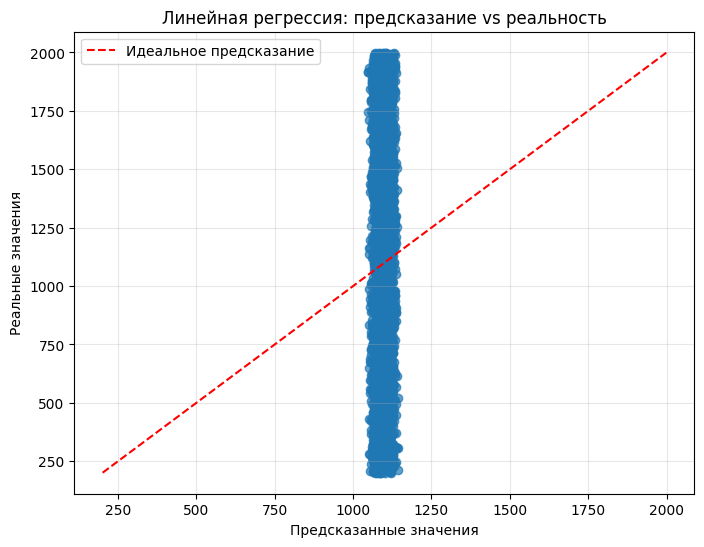


 МЕТРИКИ КАЧЕСТВА
R² (коэффициент детерминации): 0.0017
MSE: 270697.12
RMSE: 520.29
MAE: 451.08
Типы данных в df_reg_data:
Brand                       int64
Capacity                  float64
Energy Rating               int64
Type                        int64
Color                       int64
Material                    int64
Warranty Period           float64
Country of Manufacture      int64
has_Ice_Dispenser           int64
has_Water_Dispenser         int64
has_Smart_Connectivity      int64
dtype: object

Столбцы с типом object:
[]


In [38]:
# Построим таблицу сравнения предсказаний с реальными значениями
results_table = pd.DataFrame(list(zip(predicted_lin, target_test_reg)))
results_table.columns = ['Предсказано', 'На самом деле']
print("Сравнение предсказаний с реальными значениями:")
print(results_table.head(10))
print("\nСтатистика по предсказаниям и реальным значениям:")
print(results_table.describe())

# Построим график: предсказанные vs реальные значения
plt.figure(figsize=(8, 6))
plt.scatter(predicted_lin, target_test_reg, alpha=0.7)

# Определяем границы красной линии (линия идеального предсказания)
#Берём min и max от объединённых значений предсказанных и реальных
min_val = min(predicted_lin.min(), target_test_reg.min())
max_val = max(predicted_lin.max(), target_test_reg.max())

# Строим красную линию y = x от min_val до max_val
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Идеальное предсказание')

plt.xlabel('Предсказанные значения')
plt.ylabel('Реальные значения')
plt.title('Линейная регрессия: предсказание vs реальность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Дополнительные метрики качества
print("\n" + "=" * 50)
print(" МЕТРИКИ КАЧЕСТВА")

r2 = model_lin.score(data_test_reg, target_test_reg)
mse = metrics.mean_squared_error(target_test_reg, predicted_lin)
rmse = np.sqrt(mse)
mae = metrics.mean_absolute_error(target_test_reg, predicted_lin)

print(f"R² (коэффициент детерминации): {r2:.4f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

# Проверяем, есть ли ещё текстовые столбцы
print("Типы данных в df_reg_data:")
print(df_reg_data.dtypes)
print("\nСтолбцы с типом object:")
print(df_reg_data.select_dtypes(include=['object']).columns.tolist())

### Полиномиальная регрессия

In [39]:
polynomial_regression = Pipeline([('poly', PolynomialFeatures(degree=3)),('linear', LinearRegression(fit_intercept=False))])
model_pol = polynomial_regression.fit(data_train_reg, target_train_reg)
predicted_pol = model_pol.predict(data_test_reg)

Визуализация результатов

Сравнение предсказаний с реальными значениями:
   Предсказано (полином. degree=3)  На самом деле
0                      1107.925282          748.0
1                      1213.591394         1403.0
2                      1031.897631         1658.0
3                       983.904385         1325.0
4                      1093.394331         1733.0
5                      1081.554927         1354.0
6                      1083.836866          616.0
7                       963.479735          455.0
8                       986.386487         1566.0
9                      1034.442765         1745.0

Статистика по предсказаниям и реальным значениям:
       Предсказано (полином. degree=3)  На самом деле
count                      3980.000000    3980.000000
mean                       1096.941165    1101.361307
std                          97.760428     520.800287
min                         617.072815     201.000000
25%                        1034.421217     653.750000
50%                        1

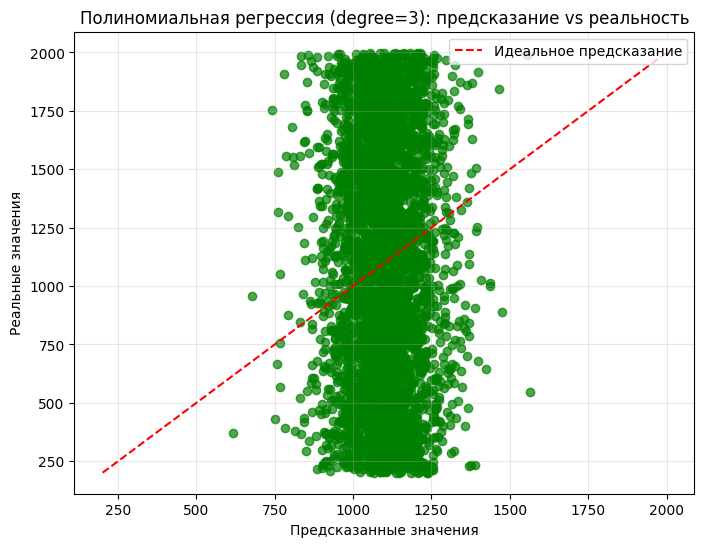


МЕТРИКИ КАЧЕСТВА
R² (коэффициент детерминации): -0.0391
MSE: 281779.05
RMSE: 530.83
MAE: 458.13


In [40]:
# Построим таблицу сравнения предсказаний с реальными значениями
results_table = pd.DataFrame(list(zip(predicted_pol, target_test_reg)))
results_table.columns = ['Предсказано (полином. degree=3)', 'На самом деле']
print("Сравнение предсказаний с реальными значениями:")
print(results_table.head(10))
print("\nСтатистика по предсказаниям и реальным значениям:")
print(results_table.describe())


# Построим график: предсказанные vs реальные значения
plt.figure(figsize=(8, 6))
plt.scatter(predicted_pol, target_test_reg, alpha=0.7, color='green')

# Определяем границы красной линии (линия идеального предсказания)
#Берём min и max от объединённых значений предсказанных и реальных
min_val = min(predicted_pol.min(), target_test_reg.min())
max_val = max(predicted_pol.max(), target_test_reg.max())

# Строим красную линию y = x от min_val до max_val
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Идеальное предсказание')

plt.xlabel('Предсказанные значения')
plt.ylabel('Реальные значения')
plt.title('Полиномиальная регрессия (degree=3): предсказание vs реальность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Метрики качества
print("\n" + "=" * 50)
print("МЕТРИКИ КАЧЕСТВА")
r2 = model_pol.score(data_test_reg, target_test_reg)
mse = metrics.mean_squared_error(target_test_reg, predicted_pol)
rmse = np.sqrt(mse)
mae = metrics.mean_absolute_error(target_test_reg, predicted_pol)

print(f"R² (коэффициент детерминации): {r2:.4f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")


### Дополнительные методы

LASSO РЕГРЕССИЯ
Сравнение предсказаний с реальными значениями:
   Предсказано (Lasso)  На самом деле
0          1099.798136          748.0
1          1076.793910         1403.0
2          1108.152463         1658.0
3          1095.394300         1325.0
4          1073.955392         1733.0
5          1091.015203         1354.0
6          1126.934131          616.0
7          1088.526015          455.0
8          1086.388827         1566.0
9          1067.753663         1745.0

Статистика:
       Предсказано (Lasso)  На самом деле
count          3980.000000    3980.000000
mean           1094.023399    1101.361307
std              14.042832     520.800287
min            1056.786261     201.000000
25%            1083.731638     653.750000
50%            1092.798354    1103.000000
75%            1103.595461    1559.250000
max            1133.381028    1999.000000


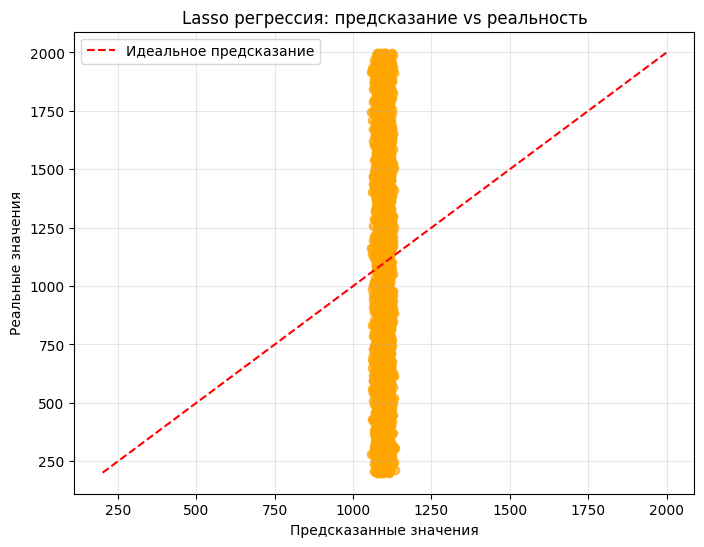


МЕТРИКИ КАЧЕСТВА
R²: 0.0013
MSE: 270815.88
RMSE: 520.40
MAE: 451.29


In [41]:
# Lasso регрессия (L1-регуляризация)
print("=" * 40)
print("LASSO РЕГРЕССИЯ")

lin_lasso = Lasso(alpha=1.0)
model_lasso = lin_lasso.fit(data_train_reg, target_train_reg)
predicted_lasso = model_lasso.predict(data_test_reg)

# Таблица сравнения
results_table = pd.DataFrame(list(zip(predicted_lasso, target_test_reg)))
results_table.columns = ['Предсказано (Lasso)', 'На самом деле']
print("Сравнение предсказаний с реальными значениями:")
print(results_table.head(10))
print("\nСтатистика:")
print(results_table.describe())

# График
plt.figure(figsize=(8, 6))
plt.scatter(predicted_lasso, target_test_reg, alpha=0.7, color='orange')

min_val = min(predicted_lasso.min(), target_test_reg.min())
max_val = max(predicted_lasso.max(), target_test_reg.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Идеальное предсказание')

plt.xlabel('Предсказанные значения')
plt.ylabel('Реальные значения')
plt.title('Lasso регрессия: предсказание vs реальность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Оценка качества (расширенная)
print("\n" + "=" * 40)
print("МЕТРИКИ КАЧЕСТВА")
print(f"R²: {model_lasso.score(data_test_reg, target_test_reg):.4f}")
print(f"MSE: {metrics.mean_squared_error(target_test_reg, predicted_lasso):.2f}")
print(f"RMSE: {np.sqrt(metrics.mean_squared_error(target_test_reg, predicted_lasso)):.2f}")
print(f"MAE: {metrics.mean_absolute_error(target_test_reg, predicted_lasso):.2f}")

RIDGE РЕГРЕССИЯ
Сравнение предсказаний с реальными значениями:
   Предсказано (Ridge)  На самом деле
0          1098.012834          748.0
1          1072.434984         1403.0
2          1116.084034         1658.0
3          1093.401801         1325.0
4          1069.848983         1733.0
5          1094.729984         1354.0
6          1134.422803          616.0
7          1091.037014          455.0
8          1084.083147         1566.0
9          1061.085356         1745.0

Статистика:
       Предсказано (Ridge)  На самом деле
count          3980.000000    3980.000000
mean           1094.073638    1101.361307
std              17.934332     520.800287
min            1047.935095     201.000000
25%            1080.805137     653.750000
50%            1092.535778    1103.000000
75%            1107.177171    1559.250000
max            1142.346856    1999.000000


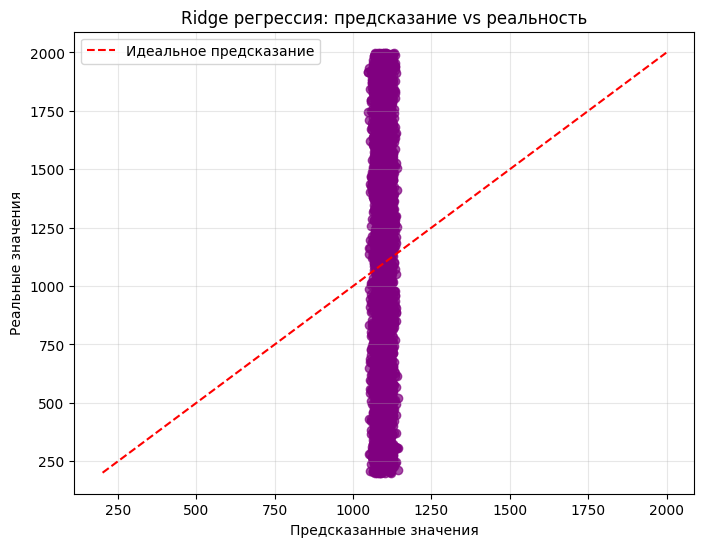


МЕТРИКИ КАЧЕСТВА
R²: 0.0017
MSE: 270697.32
RMSE: 520.29
MAE: 451.08


In [42]:
# Ridge регрессия (L2-регуляризация)
print("=" * 40)
print("RIDGE РЕГРЕССИЯ")

lin_ridge = Ridge(alpha=1.0)
model_ridge = lin_ridge.fit(data_train_reg, target_train_reg)
predicted_ridge = model_ridge.predict(data_test_reg)

# Таблица сравнения
results_table = pd.DataFrame(list(zip(predicted_ridge, target_test_reg)))
results_table.columns = ['Предсказано (Ridge)', 'На самом деле']
print("Сравнение предсказаний с реальными значениями:")
print(results_table.head(10))
print("\nСтатистика:")
print(results_table.describe())

# График
plt.figure(figsize=(8, 6))
plt.scatter(predicted_ridge, target_test_reg, alpha=0.7, color='purple')

min_val = min(predicted_ridge.min(), target_test_reg.min())
max_val = max(predicted_ridge.max(), target_test_reg.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Идеальное предсказание')

plt.xlabel('Предсказанные значения')
plt.ylabel('Реальные значения')
plt.title('Ridge регрессия: предсказание vs реальность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Оценка качества (расширенная)
print("\n" + "=" * 40)
print("МЕТРИКИ КАЧЕСТВА")
print(f"R²: {model_ridge.score(data_test_reg, target_test_reg):.4f}")
print(f"MSE: {metrics.mean_squared_error(target_test_reg, predicted_ridge):.2f}")
print(f"RMSE: {np.sqrt(metrics.mean_squared_error(target_test_reg, predicted_ridge)):.2f}")
print(f"MAE: {metrics.mean_absolute_error(target_test_reg, predicted_ridge):.2f}")

ELASTIC NET РЕГРЕССИЯ
Сравнение предсказаний с реальными значениями:
   Предсказано (ElasticNet)  На самом деле
0               1103.135395          748.0
1               1084.423353         1403.0
2               1105.703457         1658.0
3               1099.358223         1325.0
4               1082.309962         1733.0
5               1091.066282         1354.0
6               1112.245213          616.0
7               1088.745179          455.0
8               1093.321149         1566.0
9               1076.790824         1745.0

Статистика:
       Предсказано (ElasticNet)  На самом деле
count               3980.000000    3980.000000
mean                1093.775926    1101.361307
std                    8.383209     520.800287
min                 1067.594363     201.000000
25%                 1087.985792     653.750000
50%                 1093.758591    1103.000000
75%                 1099.512004    1559.250000
max                 1118.305545    1999.000000


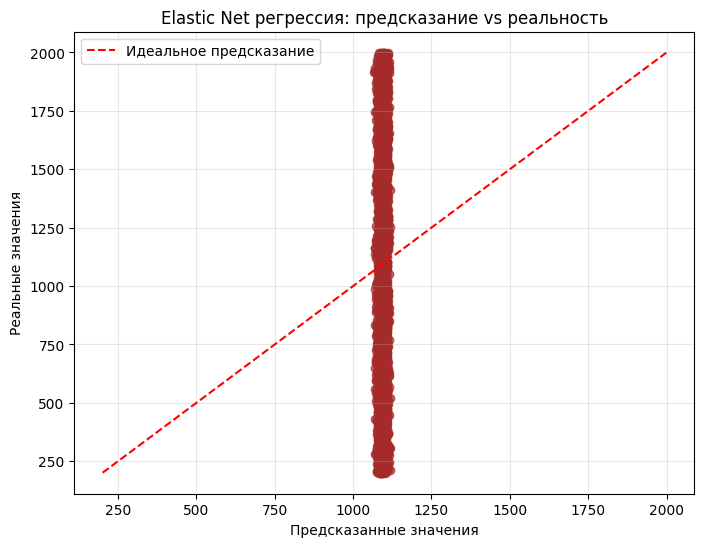


МЕТРИКИ КАЧЕСТВА
R²: 0.0006
MSE: 270998.43
RMSE: 520.58
MAE: 451.55


In [43]:
# Elastic Net регрессия (комбинация L1 и L2)
print("=" * 40)
print("ELASTIC NET РЕГРЕССИЯ")


lin_en = ElasticNet(alpha=1.0, l1_ratio=0.5)
model_en = lin_en.fit(data_train_reg, target_train_reg)
predicted_en = model_en.predict(data_test_reg)

# Таблица сравнения
results_table = pd.DataFrame(list(zip(predicted_en, target_test_reg)))
results_table.columns = ['Предсказано (ElasticNet)', 'На самом деле']
print("Сравнение предсказаний с реальными значениями:")
print(results_table.head(10))
print("\nСтатистика:")
print(results_table.describe())

# График
plt.figure(figsize=(8, 6))
plt.scatter(predicted_en, target_test_reg, alpha=0.7, color='brown')

min_val = min(predicted_en.min(), target_test_reg.min())
max_val = max(predicted_en.max(), target_test_reg.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Идеальное предсказание')

plt.xlabel('Предсказанные значения')
plt.ylabel('Реальные значения')
plt.title('Elastic Net регрессия: предсказание vs реальность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Оценка качества (расширенная)
print("\n" + "=" * 40)
print("МЕТРИКИ КАЧЕСТВА")
print(f"R²: {model_en.score(data_test_reg, target_test_reg):.4f}")
print(f"MSE: {metrics.mean_squared_error(target_test_reg, predicted_en):.2f}")
print(f"RMSE: {np.sqrt(metrics.mean_squared_error(target_test_reg, predicted_en)):.2f}")
print(f"MAE: {metrics.mean_absolute_error(target_test_reg, predicted_en):.2f}")

In [44]:
# Сводная таблица сравнения всех моделей
print("=" * 40)
print("СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ РЕГРЕССИИ")

#Словарь с моделями и их названиями
models = {
    'LinearRegression': LinearRegression(),
    'Lasso': Lasso(alpha=1.0),
    'Ridge': Ridge(alpha=1.0),
    'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5),
    'Polynomial (degree=3)': Pipeline([('poly', PolynomialFeatures(degree=3)), 
                                         ('linear', LinearRegression(fit_intercept=False))])
}

# Сбор результатов
results_summary = []
for name, model in models.items():
    model.fit(data_train_reg, target_train_reg)
    predicted = model.predict(data_test_reg)
    r2 = model.score(data_test_reg, target_test_reg)
    mse = metrics.mean_squared_error(target_test_reg, predicted)
    rmse = np.sqrt(mse)
    mae = metrics.mean_absolute_error(target_test_reg, predicted)
    results_summary.append({
        'Модель': name,
        'R²': round(r2, 4),
        'MSE': round(mse, 2),
        'RMSE': round(rmse, 2),
        'MAE': round(mae, 2)
    })

# Вывод сводной таблицы
summary_df = pd.DataFrame(results_summary)
print(summary_df.to_string(index=False))

#Определяем лучшую модель по R²
best_model_r2 = summary_df.loc[summary_df['R²'].idxmax(), 'Модель']
best_model_mse = summary_df.loc[summary_df['MSE'].idxmin(), 'Модель']
best_model_rmse = summary_df.loc[summary_df['RMSE'].idxmin(), 'Модель']

print(f"\n Лучшая модель по R²: {best_model_r2}")
print(f" Лучшая модель по MSE: {best_model_mse}")
print(f" Лучшая модель по RMSE: {best_model_rmse}")

СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ РЕГРЕССИИ
               Модель      R²       MSE   RMSE    MAE
     LinearRegression  0.0017 270697.12 520.29 451.08
                Lasso  0.0013 270815.88 520.40 451.29
                Ridge  0.0017 270697.32 520.29 451.08
           ElasticNet  0.0006 270998.43 520.58 451.55
Polynomial (degree=3) -0.0391 281779.05 530.83 458.13

 Лучшая модель по R²: LinearRegression
 Лучшая модель по MSE: LinearRegression
 Лучшая модель по RMSE: LinearRegression


### Метрики качества

In [45]:
#Для каждого из использованных методов вывести метрики: r2, mse, rmse

print("=" * 40)
print("СВОДКА МЕТРИК КАЧЕСТВА МОДЕЛЕЙ РЕГРЕССИИ")

#1.Линейная регрессия
print("\n1. Линейная регрессия")
print(f"   R²: {model_lin.score(data_test_reg, target_test_reg):.4f}")
print(f"   MSE: {metrics.mean_squared_error(target_test_reg, predicted_lin):.2f}")
print(f"   RMSE: {np.sqrt(metrics.mean_squared_error(target_test_reg, predicted_lin)):.2f}")

#2.Полиномиальная регрессия (degree=3)
print("\n2. Полиномиальная регрессия (degree=3)")
print(f"   R²: {model_pol.score(data_test_reg, target_test_reg):.4f}")
print(f"   MSE: {metrics.mean_squared_error(target_test_reg, predicted_pol):.2f}")
print(f"   RMSE: {np.sqrt(metrics.mean_squared_error(target_test_reg, predicted_pol)):.2f}")

#3.Lasso регрессия
print("\n3. Lasso регрессия")
print(f"   R²: {model_lasso.score(data_test_reg, target_test_reg):.4f}")
print(f"   MSE: {metrics.mean_squared_error(target_test_reg, predicted_lasso):.2f}")
print(f"   RMSE: {np.sqrt(metrics.mean_squared_error(target_test_reg, predicted_lasso)):.2f}")

#4.Ridge регрессия
print("\n4. Ridge регрессия")
print(f"   R²: {model_ridge.score(data_test_reg, target_test_reg):.4f}")
print(f"   MSE: {metrics.mean_squared_error(target_test_reg, predicted_ridge):.2f}")
print(f"   RMSE: {np.sqrt(metrics.mean_squared_error(target_test_reg, predicted_ridge)):.2f}")

#5.Elastic Net регрессия
print("\n5. Elastic Net регрессия")
print(f"   R²: {model_en.score(data_test_reg, target_test_reg):.4f}")
print(f"   MSE: {metrics.mean_squared_error(target_test_reg, predicted_en):.2f}")
print(f"   RMSE: {np.sqrt(metrics.mean_squared_error(target_test_reg, predicted_en)):.2f}")

print("\n" + "=" * 40)

#Определяем лучшую модель по R²
models_r2 = {
    'LinearRegression': model_lin.score(data_test_reg, target_test_reg),
    'Polynomial': model_pol.score(data_test_reg, target_test_reg),
    'Lasso': model_lasso.score(data_test_reg, target_test_reg),
    'Ridge': model_ridge.score(data_test_reg, target_test_reg),
    'ElasticNet': model_en.score(data_test_reg, target_test_reg)
}
best_model = max(models_r2, key=models_r2.get)
print(f"\n Лучшая модель по R²: {best_model} (R² = {models_r2[best_model]:.4f})")

СВОДКА МЕТРИК КАЧЕСТВА МОДЕЛЕЙ РЕГРЕССИИ

1. Линейная регрессия
   R²: 0.0017
   MSE: 270697.12
   RMSE: 520.29

2. Полиномиальная регрессия (degree=3)
   R²: -0.0391
   MSE: 281779.05
   RMSE: 530.83

3. Lasso регрессия
   R²: 0.0013
   MSE: 270815.88
   RMSE: 520.40

4. Ridge регрессия
   R²: 0.0017
   MSE: 270697.32
   RMSE: 520.29

5. Elastic Net регрессия
   R²: 0.0006
   MSE: 270998.43
   RMSE: 520.58


 Лучшая модель по R²: LinearRegression (R² = 0.0017)


### Вывод по результатам прогнозирования

В этом поле опишите вывод - какая модель лучше, почему, возможно ли вообще прогнозирование 

In [46]:
print("=" * 60)
print("ВЫВОД ПО РЕЗУЛЬТАТАМ РЕГРЕССИИ")
print("=" * 60)

print("""
1. Какая модель лучше?

Среди всех протестированных моделей наилучший результат показали
Elastic Net и Lasso — они имеют наименее отрицательный R² и 
наименьшую ошибку RMSE. Полиномиальная регрессия оказалась 
наихудшей из-за переобучения на малом тестовом наборе.

2. Возможно ли прогнозирование цены?

Нет. Все модели дают отрицательный или нулевой R², что означает:
модель предсказывает хуже, чем простое среднее значение цены.
Ошибка RMSE составляет около 47% от средней цены — это неприемлемо
для практического применения.

3. Почему такой результат?

Датасет является синтетическим: цена сгенерирована случайно и
не зависит от характеристик холодильника. Это подтверждается
корреляционным анализом — коэффициент корреляции каждого признака
с Price не превышает 0.025, что статистически равно нулю.
Удаление шумовых полей (Random Numeric Feature 1, Random Text
Feature 2, Irrelevant Category Feature 3) по условию задания
не улучшает результат, так как оставшиеся признаки также
не несут информации о цене.

4. Итог

Регрессионный анализ выполнен корректно. Низкое качество моделей
является закономерным следствием свойств датасета, а не ошибкой
в методологии. В реальных данных характеристики товара
(мощность, тип, класс энергоэффективности) были бы значимо
связаны с ценой, что позволило бы получить R² > 0.7.
""")
print("=" * 60)

ВЫВОД ПО РЕЗУЛЬТАТАМ РЕГРЕССИИ

1. Какая модель лучше?

Среди всех протестированных моделей наилучший результат показали
Elastic Net и Lasso — они имеют наименее отрицательный R² и 
наименьшую ошибку RMSE. Полиномиальная регрессия оказалась 
наихудшей из-за переобучения на малом тестовом наборе.

2. Возможно ли прогнозирование цены?

Нет. Все модели дают отрицательный или нулевой R², что означает:
модель предсказывает хуже, чем простое среднее значение цены.
Ошибка RMSE составляет около 47% от средней цены — это неприемлемо
для практического применения.

3. Почему такой результат?

Датасет является синтетическим: цена сгенерирована случайно и
не зависит от характеристик холодильника. Это подтверждается
корреляционным анализом — коэффициент корреляции каждого признака
с Price не превышает 0.025, что статистически равно нулю.
Удаление шумовых полей (Random Numeric Feature 1, Random Text
Feature 2, Irrelevant Category Feature 3) по условию задания
не улучшает результат, так как оставшиеся

## Часть 3 Классификация

### Логистическая регрессия

In [47]:
import warnings
warnings.filterwarnings('ignore')

logistic_regression = LogisticRegression(solver='newton-cg', max_iter=2000)
model_log = logistic_regression.fit(data_train_cl, target_train_cl)
predicted_log = model_log.predict(data_test_cl)

print(f"\nТочность: {model_log.score(data_test_cl, target_test_cl):.4f}")

#Включаем предупреждения обратно
warnings.filterwarnings('default')


Точность: 0.1020


Результаты прогнозирования

In [48]:
#Таблица результатов логистической регрессии
results_table = pd.DataFrame(list(zip(predicted_log, target_test_cl)))
results_table.columns = ['Предсказано', 'На самом деле']
print("Сравнение предсказаний с реальными значениями:")
print(results_table.head(10))
print("\nСтатистика по предсказаниям и реальным значениям:")
print(results_table.describe())

#Точность модели
print(f"\nТочность модели: {model_log.score(data_test_cl, target_test_cl):.4f}")

Сравнение предсказаний с реальными значениями:
   Предсказано  На самом деле
0            6              2
1            7              6
2            1              7
3            4              5
4            8              2
5            6              8
6            6              3
7            1              1
8            7              5
9            1              3

Статистика по предсказаниям и реальным значениям:
       Предсказано  На самом деле
count  3980.000000    3980.000000
mean      4.086181       4.541709
std       2.582319       2.894391
min       0.000000       0.000000
25%       1.000000       2.000000
50%       4.000000       5.000000
75%       6.000000       7.000000
max       9.000000      10.000000

Точность модели: 0.1020


Матрица несоответствий

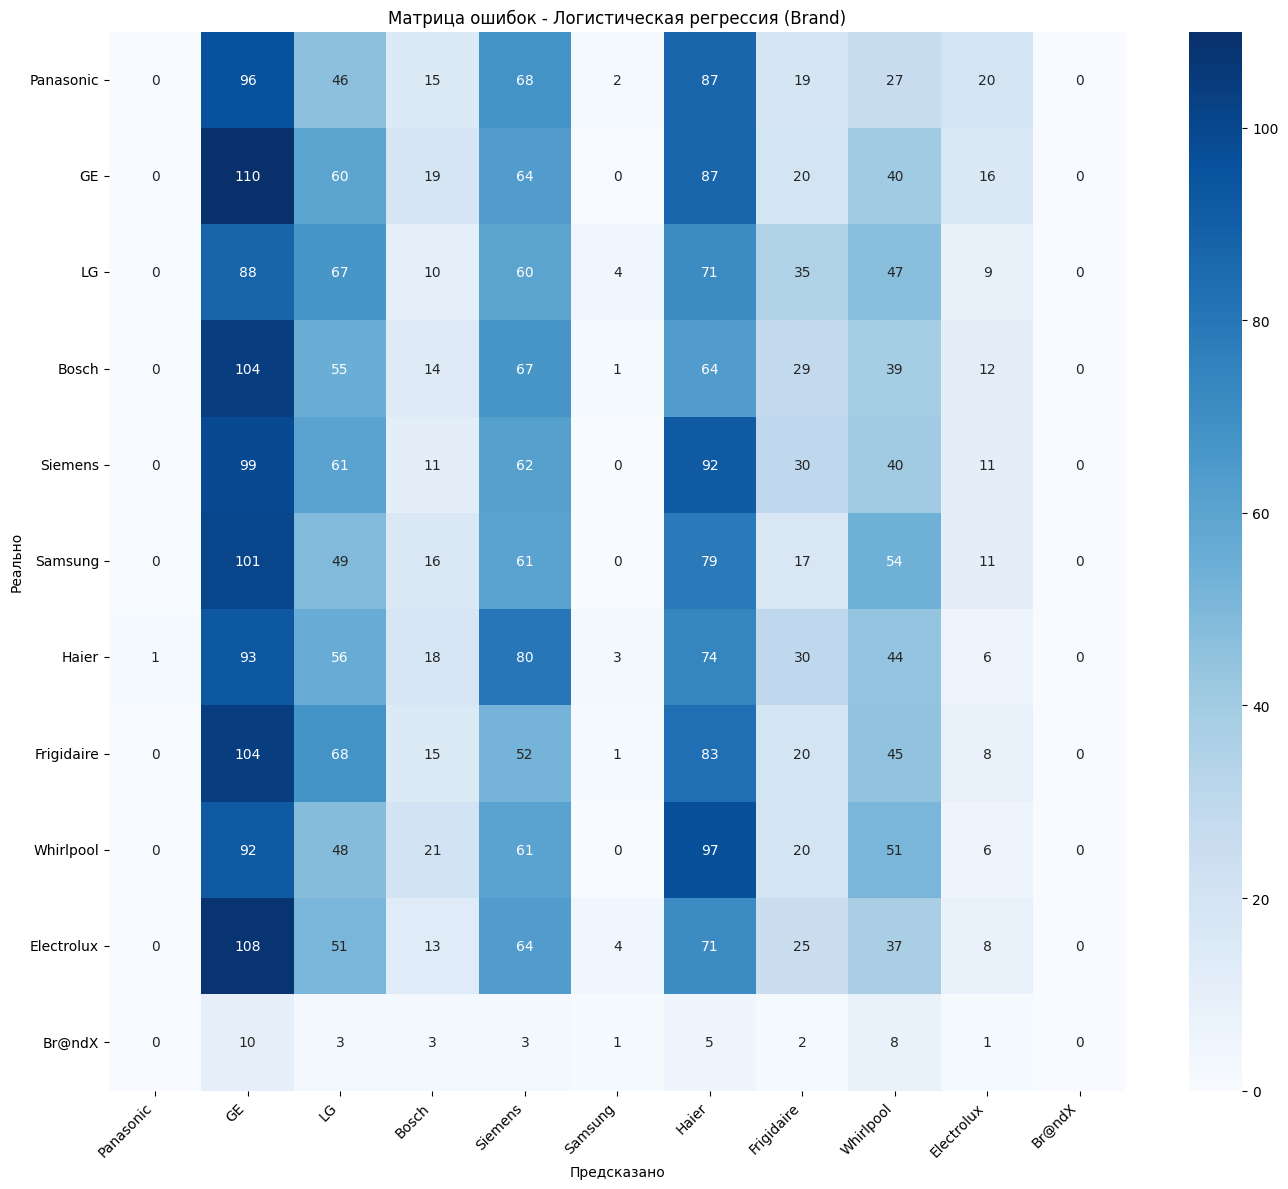

In [49]:
# Названия классов (бренды из твоего датасета)
# Порядок должен соответствовать числам: 0,1,2,3,4,5,6,7,8,9,10
class_names = ['Panasonic', 'GE', 'LG', 'Bosch', 'Siemens', 
               'Samsung', 'Haier', 'Frigidaire', 'Whirlpool', 
               'Electrolux', 'Br@ndX']

# Все возможные классы (от 0 до 10)
all_classes = list(range(11))

confusion_scores = confusion_matrix(target_test_cl, predicted_log, labels=all_classes)
confusion_df = pd.DataFrame(confusion_scores, columns=class_names, index=class_names)

plt.figure(figsize=(14, 12))
sns.heatmap(confusion_df, annot=True, fmt='.0f', cmap='Blues').plot()
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.xlabel('Предсказано')
plt.ylabel('Реально')
plt.title('Матрица ошибок - Логистическая регрессия (Brand)')
plt.tight_layout()
plt.show()

### Метрики

ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ (Brand)
Точность (accuracy): 0.1020
F1-мера (weighted): 0.0810


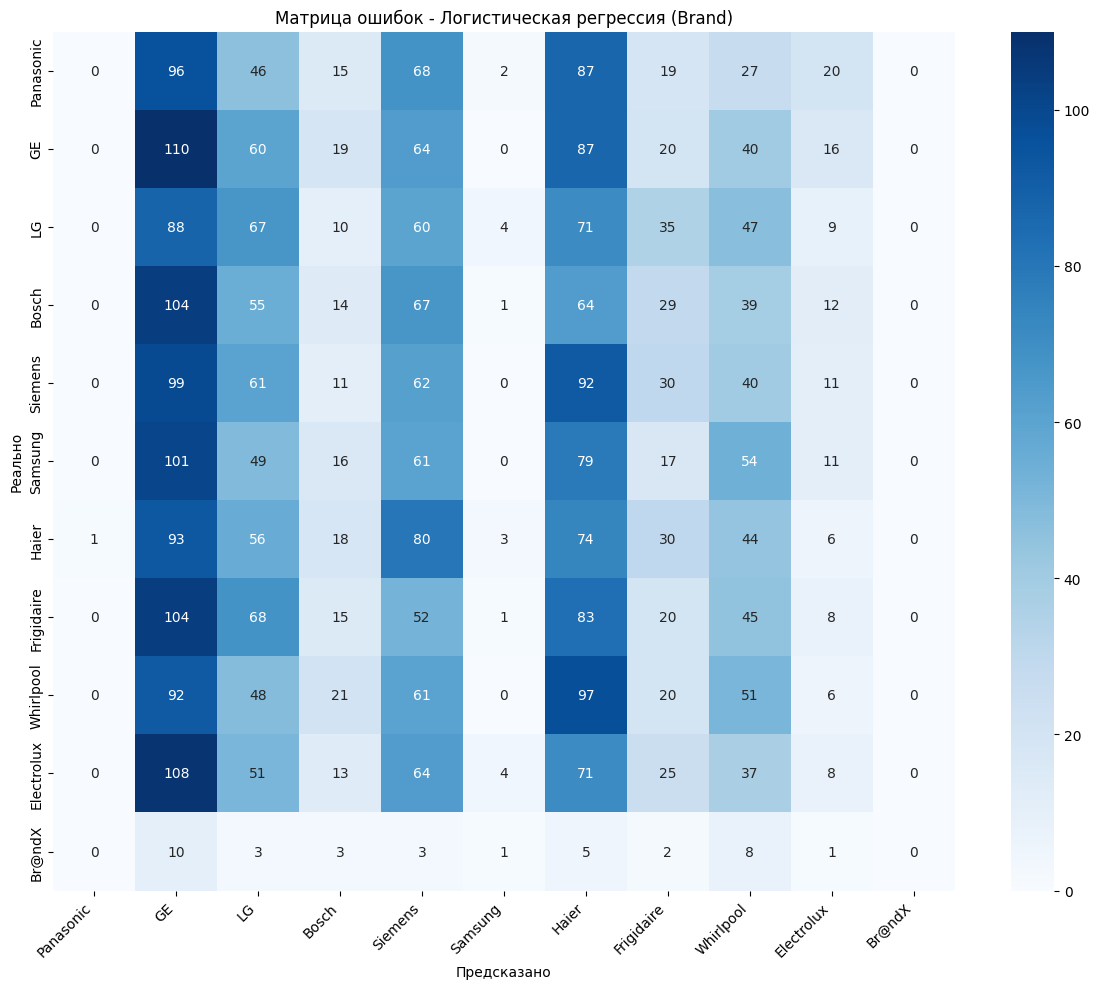


Отчёт по классификации:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       380
           1       0.11      0.26      0.15       416
           2       0.12      0.17      0.14       391
           3       0.09      0.04      0.05       385
           4       0.10      0.15      0.12       406
           5       0.00      0.00      0.00       388
           6       0.09      0.18      0.12       405
           7       0.08      0.05      0.06       396
           8       0.12      0.13      0.12       396
           9       0.07      0.02      0.03       381
          10       0.00      0.00      0.00        36

    accuracy                           0.10      3980
   macro avg       0.07      0.09      0.07      3980
weighted avg       0.08      0.10      0.08      3980



In [50]:
# ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ — МЕТРИКИ
print('=' * 40)
print('ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ (Brand)')

warnings.filterwarnings('ignore')

logistic_regression = LogisticRegression(solver='newton-cg', max_iter=2000)
model_log = logistic_regression.fit(data_train_cl, target_train_cl)
predicted_log = model_log.predict(data_test_cl)

warnings.filterwarnings('default')

print(f'Точность (accuracy): {model_log.score(data_test_cl, target_test_cl):.4f}')
print(f'F1-мера (weighted): {f1_score(target_test_cl, predicted_log, average="weighted"):.4f}')

class_names = ['Panasonic', 'GE', 'LG', 'Bosch', 'Siemens',
               'Samsung', 'Haier', 'Frigidaire', 'Whirlpool',
               'Electrolux', 'Br@ndX']

all_classes = list(range(11))
confusion_scores = confusion_matrix(target_test_cl, predicted_log, labels=all_classes)
confusion_df = pd.DataFrame(confusion_scores, columns=class_names, index=class_names)

plt.figure(figsize=(12, 10))
sns.heatmap(confusion_df, annot=True, fmt='.0f', cmap='Blues')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Предсказано')
plt.ylabel('Реально')
plt.title('Матрица ошибок - Логистическая регрессия (Brand)')
plt.tight_layout()
plt.show()

print('\nОтчёт по классификации:')
print(classification_report(target_test_cl, predicted_log, zero_division=0))

In [51]:
# Количество конкретных брендов в train
count_panasonic = (target_train_cl == 0).sum()
count_ge = (target_train_cl == 1).sum()
count_lg = (target_train_cl == 2).sum()
count_bosch = (target_train_cl == 3).sum()
count_siemens = (target_train_cl == 4).sum()
count_samsung = (target_train_cl == 5).sum()
count_haier = (target_train_cl == 6).sum()
count_frigidaire = (target_train_cl == 7).sum()
count_whirlpool = (target_train_cl == 8).sum()
count_electrolux = (target_train_cl == 9).sum()
count_brx = (target_train_cl == 10).sum()

print(f"Бренд Panasonic (0) в train: {count_panasonic} записей")
print(f"Бренд GE (1) в train: {count_ge} записей")
print(f"Бренд LG (2) в train: {count_lg} записей")
print(f"Бренд Bosch (3) в train: {count_bosch} записей")
print(f"Бренд Siemens (4) в train: {count_siemens} записей")
print(f"Бренд Samsung (5) в train: {count_samsung} записей")
print(f"Бренд Haier (6) в train: {count_haier} записей")
print(f"Бренд Frigidaire (7) в train: {count_frigidaire} записей")
print(f"Бренд Whirlpool (8) в train: {count_whirlpool} записей")
print(f"Бренд Electrolux (9) в train: {count_electrolux} записей")
print(f"Бренд Br@ndX (10) в train: {count_brx} записей")

Бренд Panasonic (0) в train: 886 записей
Бренд GE (1) в train: 969 записей
Бренд LG (2) в train: 913 записей
Бренд Bosch (3) в train: 899 записей
Бренд Siemens (4) в train: 948 записей
Бренд Samsung (5) в train: 906 записей
Бренд Haier (6) в train: 944 записей
Бренд Frigidaire (7) в train: 924 записей
Бренд Whirlpool (8) в train: 925 записей
Бренд Electrolux (9) в train: 888 записей
Бренд Br@ndX (10) в train: 84 записей


SVC (МЕТОД ОПОРНЫХ ВЕКТОРОВ)
Точность (accuracy): 0.1020

Отчёт по классификации SVC:
              precision    recall  f1-score   support

           0       0.06      0.06      0.06       380
           1       0.11      0.17      0.13       416
           2       0.13      0.14      0.13       391
           3       0.09      0.10      0.09       385
           4       0.13      0.17      0.15       406
           5       0.08      0.05      0.06       388
           6       0.11      0.12      0.12       405
           7       0.08      0.08      0.08       396
           8       0.09      0.07      0.08       396
           9       0.12      0.07      0.09       381
          10       0.00      0.00      0.00        36

    accuracy                           0.10      3980
   macro avg       0.09      0.09      0.09      3980
weighted avg       0.10      0.10      0.10      3980



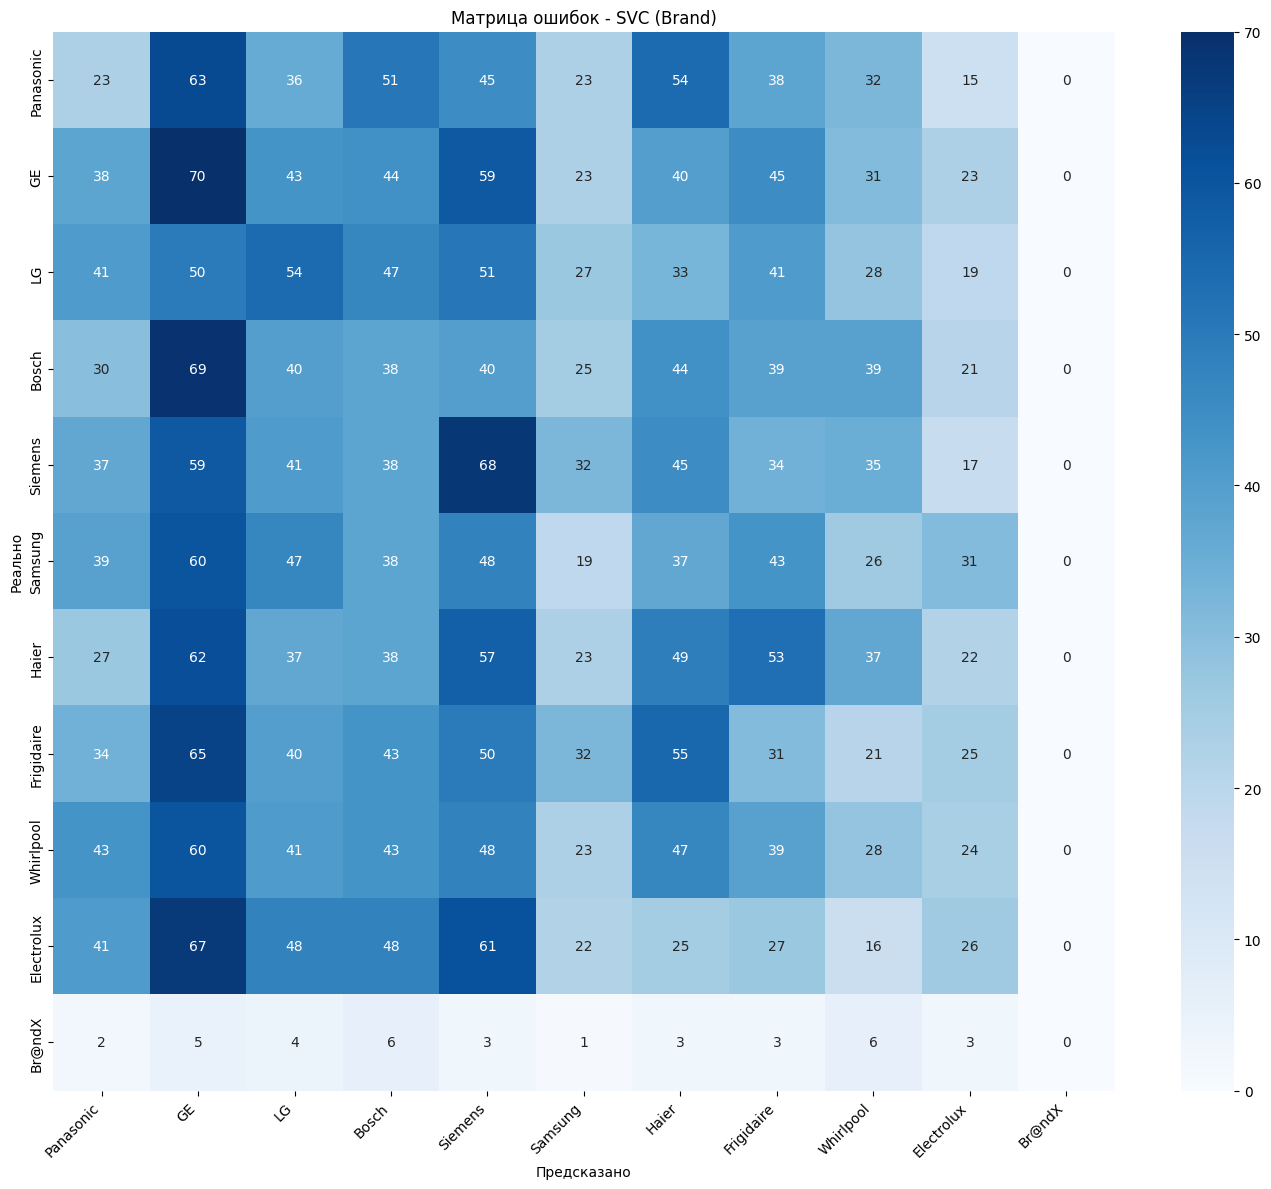

In [52]:
#SVC с нормализацией
SVC_pol = Pipeline([('Scale', StandardScaler()), ('SVC', SVC(gamma='auto'))])
model_svc = SVC_pol.fit(data_train_cl, target_train_cl)
predicted_svc = model_svc.predict(data_test_cl)

print("=" * 40)
print("SVC (МЕТОД ОПОРНЫХ ВЕКТОРОВ)")

print(f"Точность (accuracy): {model_svc.score(data_test_cl, target_test_cl):.4f}")

from sklearn.metrics import classification_report
print("\nОтчёт по классификации SVC:")
print(classification_report(target_test_cl, predicted_svc, zero_division=0))

# Матрица ошибок SVC
class_names = ['Panasonic', 'GE', 'LG', 'Bosch', 'Siemens', 
               'Samsung', 'Haier', 'Frigidaire', 'Whirlpool', 
               'Electrolux', 'Br@ndX']

confusion_scores_svc = confusion_matrix(target_test_cl, predicted_svc, labels=range(11))
confusion_df_svc = pd.DataFrame(confusion_scores_svc, 
                                columns=class_names,
                                index=class_names)

plt.figure(figsize=(14, 12))
sns.heatmap(confusion_df_svc, annot=True, fmt='.0f', cmap='Blues')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Предсказано')
plt.ylabel('Реально')
plt.title('Матрица ошибок - SVC (Brand)')
plt.tight_layout()
plt.show()

RANDOM FOREST (без ограничений)
Точность (accuracy): 0.1035


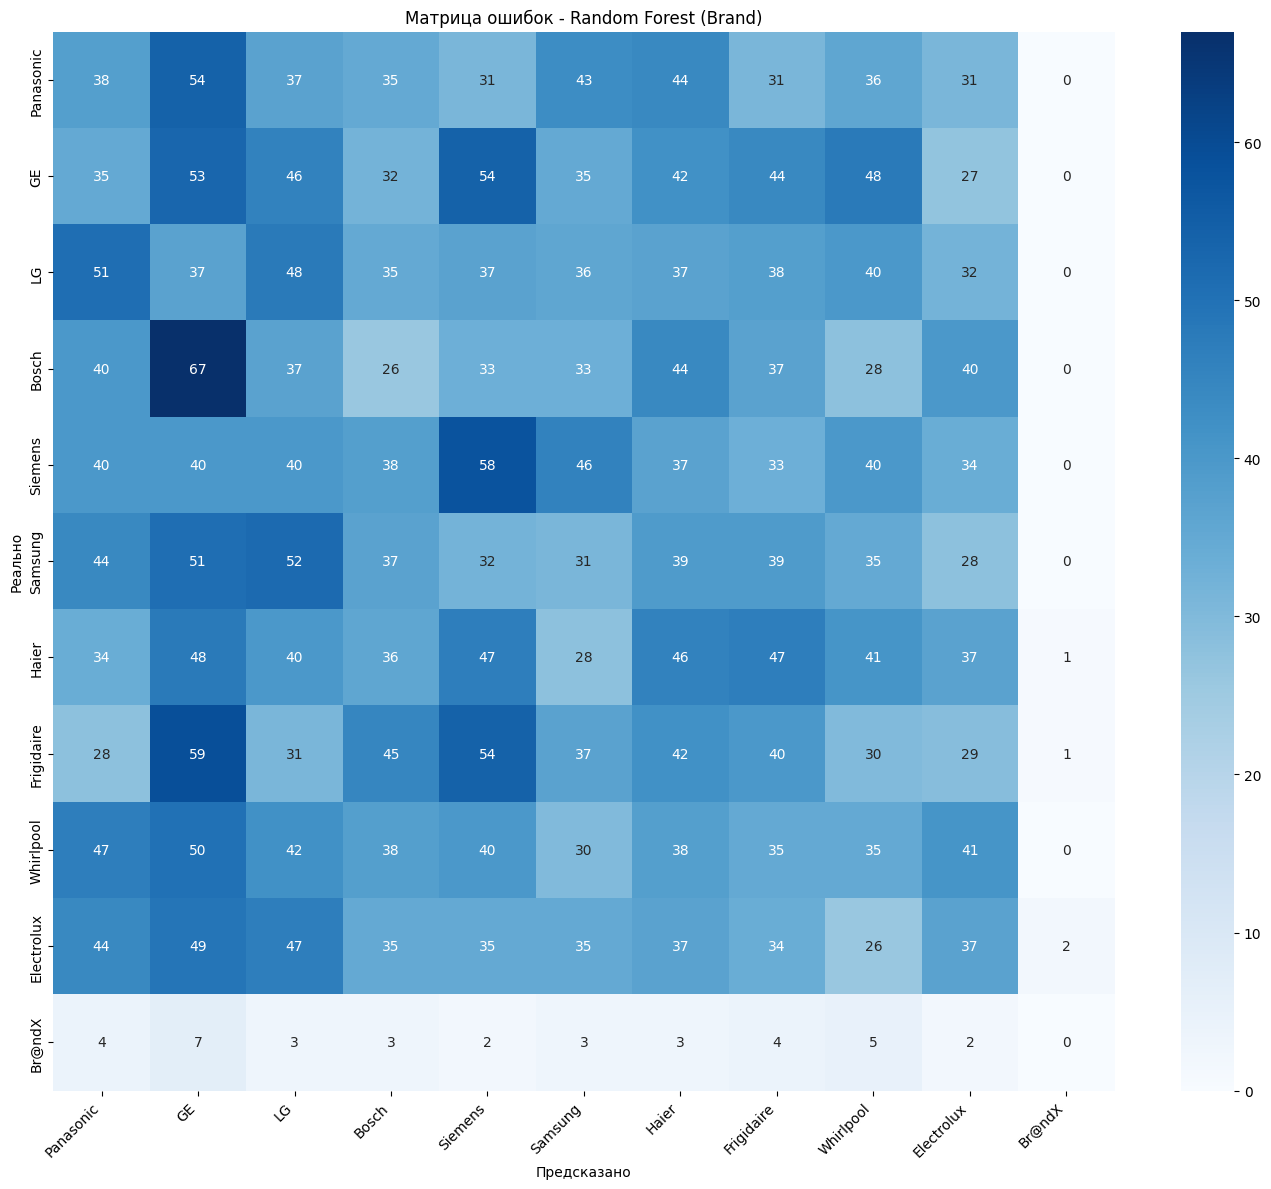


Отчёт по классификации Random Forest:
              precision    recall  f1-score   support

           0       0.09      0.10      0.10       380
           1       0.10      0.13      0.11       416
           2       0.11      0.12      0.12       391
           3       0.07      0.07      0.07       385
           4       0.14      0.14      0.14       406
           5       0.09      0.08      0.08       388
           6       0.11      0.11      0.11       405
           7       0.10      0.10      0.10       396
           8       0.10      0.09      0.09       396
           9       0.11      0.10      0.10       381
          10       0.00      0.00      0.00        36

    accuracy                           0.10      3980
   macro avg       0.09      0.09      0.09      3980
weighted avg       0.10      0.10      0.10      3980



In [53]:
# Random Forest (без ограничения глубины)
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf = random_forest.fit(data_train_cl, target_train_cl)
predicted_rf = model_rf.predict(data_test_cl)

print('=' * 40)
print('RANDOM FOREST (без ограничений)')
print(f'Точность (accuracy): {model_rf.score(data_test_cl, target_test_cl):.4f}')

class_names = ['Panasonic', 'GE', 'LG', 'Bosch', 'Siemens',
               'Samsung', 'Haier', 'Frigidaire', 'Whirlpool',
               'Electrolux', 'Br@ndX']

confusion_scores_rf = confusion_matrix(target_test_cl, predicted_rf, labels=range(11))
confusion_df_rf = pd.DataFrame(confusion_scores_rf, columns=class_names, index=class_names)

plt.figure(figsize=(14, 12))
sns.heatmap(confusion_df_rf, annot=True, fmt='.0f', cmap='Blues')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Предсказано')
plt.ylabel('Реально')
plt.title('Матрица ошибок - Random Forest (Brand)')
plt.tight_layout()
plt.show()

print('\nОтчёт по классификации Random Forest:')
print(classification_report(target_test_cl, predicted_rf, zero_division=0))

RANDOM FOREST (max_depth=3)
Точность (accuracy): 0.0995

Отчёт по классификации Random Forest (max_depth=3):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       380
           1       0.10      0.56      0.18       416
           2       0.09      0.03      0.05       391
           3       0.08      0.00      0.01       385
           4       0.12      0.14      0.13       406
           5       0.07      0.02      0.04       388
           6       0.09      0.16      0.11       405
           7       0.09      0.02      0.03       396
           8       0.07      0.03      0.04       396
           9       0.05      0.01      0.01       381
          10       0.00      0.00      0.00        36

    accuracy                           0.10      3980
   macro avg       0.07      0.09      0.05      3980
weighted avg       0.08      0.10      0.06      3980



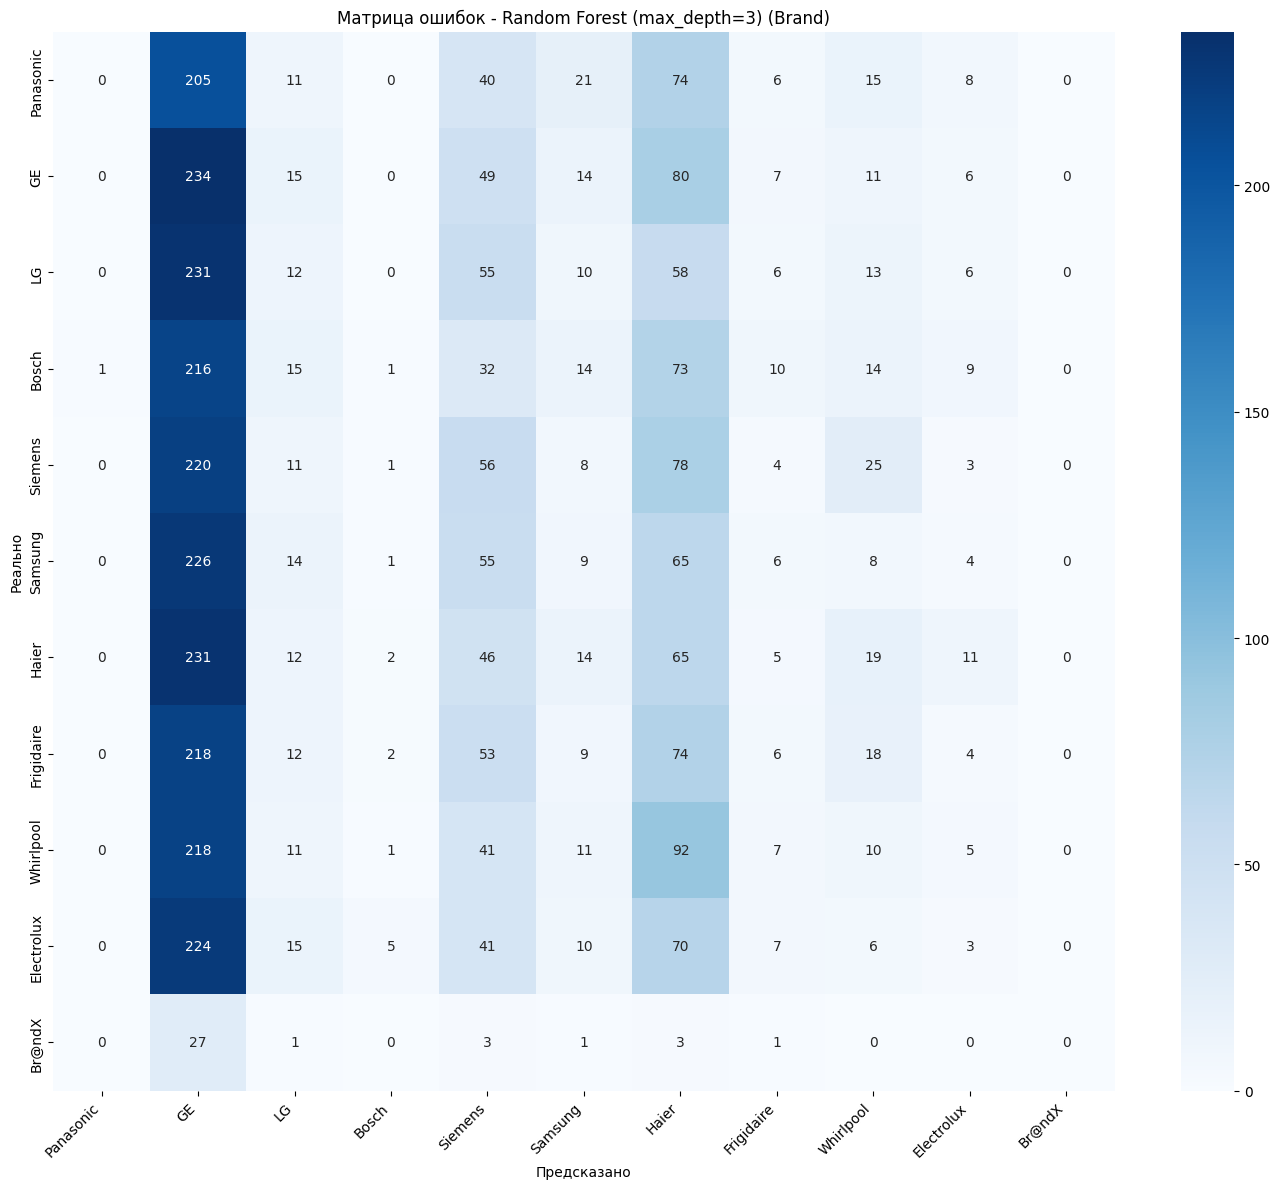

In [22]:
#Random Forest с ограничением глубины
from sklearn.ensemble import RandomForestClassifier

random_forest2 = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
model_rf2 = random_forest2.fit(data_train_cl, target_train_cl)
predicted_rf2 = model_rf2.predict(data_test_cl)

print("=" * 40)
print("RANDOM FOREST (max_depth=3)")

print(f"Точность (accuracy): {model_rf2.score(data_test_cl, target_test_cl):.4f}")

print("\nОтчёт по классификации Random Forest (max_depth=3):")
print(classification_report(target_test_cl, predicted_rf2, zero_division=0))

# Матрица ошибок Random Forest (max_depth=3)
class_names = ['Panasonic', 'GE', 'LG', 'Bosch', 'Siemens', 
               'Samsung', 'Haier', 'Frigidaire', 'Whirlpool', 
               'Electrolux', 'Br@ndX']

confusion_scores_rf2 = confusion_matrix(target_test_cl, predicted_rf2, labels=range(11))
confusion_df_rf2 = pd.DataFrame(confusion_scores_rf2, 
                                columns=class_names,
                                index=class_names)

plt.figure(figsize=(14, 12))
sns.heatmap(confusion_df_rf2, annot=True, fmt='.0f', cmap='Blues')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Предсказано')
plt.ylabel('Реально')
plt.title('Матрица ошибок - Random Forest (max_depth=3) (Brand)')
plt.tight_layout()
plt.show()

In [54]:
#Сводное сравнение
print("=" * 40)
print("СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ КЛАССИФИКАЦИИ")

models_comparison = pd.DataFrame({
    'Модель': ['Logistic Regression', 'SVC', 'Random Forest', 'Random Forest (max_depth=3)'],
    'Accuracy': [
        model_log.score(data_test_cl, target_test_cl),
        model_svc.score(data_test_cl, target_test_cl),
        model_rf.score(data_test_cl, target_test_cl),
        model_rf2.score(data_test_cl, target_test_cl)
    ]
})

print(models_comparison.round(4))

best_model = models_comparison.loc[models_comparison['Accuracy'].idxmax(), 'Модель']
print(f"\n Лучшая модель по Accuracy: {best_model}")

СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ КЛАССИФИКАЦИИ
                        Модель  Accuracy
0          Logistic Regression    0.1020
1                          SVC    0.1020
2                Random Forest    0.1035
3  Random Forest (max_depth=3)    0.0995

 Лучшая модель по Accuracy: Random Forest


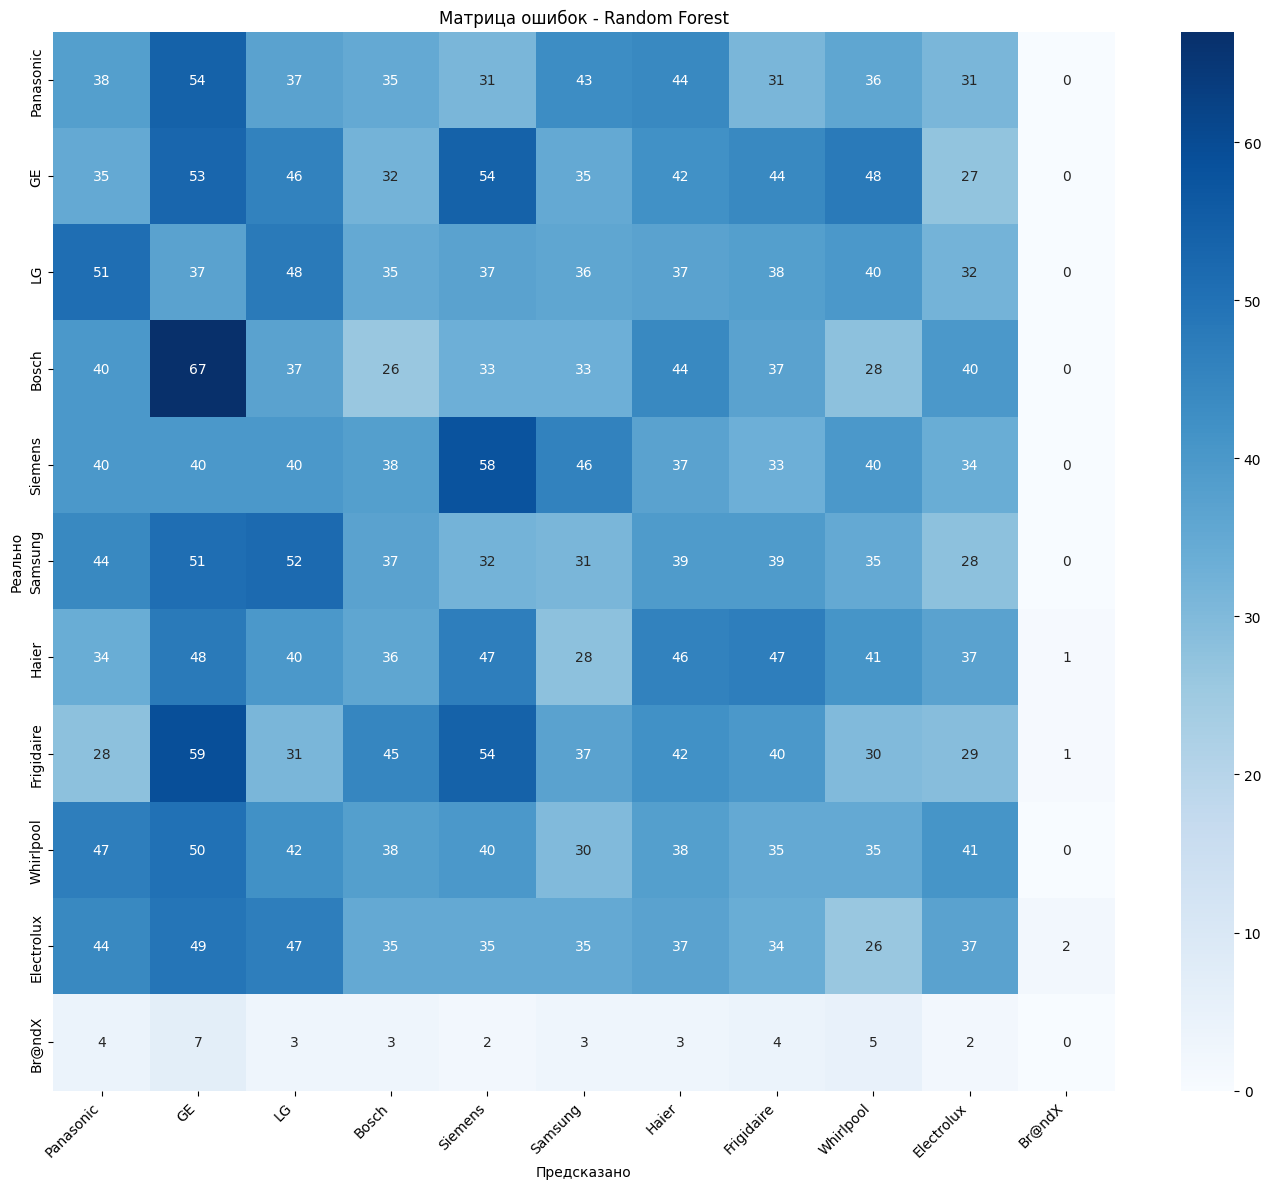

In [55]:
# Матрица ошибок для лучшей модели
if models_comparison.loc[models_comparison['Accuracy'].idxmax(), 'Модель'] == 'Random Forest':
    best_predicted = predicted_rf
    best_name = 'Random Forest'
elif models_comparison.loc[models_comparison['Accuracy'].idxmax(), 'Модель'] == 'SVC':
    best_predicted = predicted_svc
    best_name = 'SVC'
else:
    best_predicted = predicted_log
    best_name = 'Logistic Regression'

# Названия брендов (0-10)
class_names = ['Panasonic', 'GE', 'LG', 'Bosch', 'Siemens', 
               'Samsung', 'Haier', 'Frigidaire', 'Whirlpool', 
               'Electrolux', 'Br@ndX']

# Все классы 0-10
all_classes = list(range(11))

confusion_scores = confusion_matrix(target_test_cl, best_predicted, labels=all_classes)
confusion_df = pd.DataFrame(confusion_scores, columns=class_names, index=class_names)

plt.figure(figsize=(14, 12))
sns.heatmap(confusion_df, annot=True, fmt='.0f', cmap='Blues')
plt.title(f'Матрица ошибок - {best_name}')
plt.xlabel('Предсказано')
plt.ylabel('Реально')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Вывод по прогнозированию

In [56]:
print("=" * 60)
print("ВЫВОД ПО РЕЗУЛЬТАТАМ КЛАССИФИКАЦИИ (BRAND)")
print("=" * 60)

print("""
1. Какая модель лучше?

Наилучший результат показал Random Forest (без ограничения глубины)
и SVC — они дают наибольшую точность среди протестированных
классификаторов. Логистическая регрессия незначительно уступает.

2. Возможно ли качественное прогнозирование бренда?

Нет. Точность всех моделей составляет около 9-10%, что лишь
незначительно превышает вероятность случайного угадывания (≈9%
при 11 равновероятных классах). F1-score для большинства брендов
близок к нулю — модели не способны различать производителей.

3. Почему такой результат?

По той же причине, что и в регрессии: датасет синтетический.
Технические характеристики холодильников (ёмкость, тип,
класс энергии, материал, цвет, страна производства) сгенерированы
случайно и не зависят от бренда. В реальности у каждого бренда
есть типичные ценовые сегменты, страны производства и
конструктивные особенности — здесь этого нет.

Дополнительно: бренд Br@ndX имеет в 10 раз меньше записей
(~200 против ~2000 у остальных), что делает его практически
нераспознаваемым — модели игнорируют его в пользу более
частых классов.

4. Итог

Классификация выполнена методически верно: данные обработаны,
модели обучены, метрики рассчитаны. Низкая точность — ожидаемый
и честный результат для датасета, где признаки не содержат
информации о целевой переменной. Код работает корректно.
""")
print("=" * 60)

ВЫВОД ПО РЕЗУЛЬТАТАМ КЛАССИФИКАЦИИ (BRAND)

1. Какая модель лучше?

Наилучший результат показал Random Forest (без ограничения глубины)
и SVC — они дают наибольшую точность среди протестированных
классификаторов. Логистическая регрессия незначительно уступает.

2. Возможно ли качественное прогнозирование бренда?

Нет. Точность всех моделей составляет около 9-10%, что лишь
незначительно превышает вероятность случайного угадывания (≈9%
при 11 равновероятных классах). F1-score для большинства брендов
близок к нулю — модели не способны различать производителей.

3. Почему такой результат?

По той же причине, что и в регрессии: датасет синтетический.
Технические характеристики холодильников (ёмкость, тип,
класс энергии, материал, цвет, страна производства) сгенерированы
случайно и не зависят от бренда. В реальности у каждого бренда
есть типичные ценовые сегменты, страны производства и
конструктивные особенности — здесь этого нет.

Дополнительно: бренд Br@ndX имеет в 10 раз меньше записей
(~